# **Learn Ensemble Model on Load Breast Cancer data**

In [45]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split , GridSearchCV

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score , roc_auc_score

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [6]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [7]:
print(f"Features shape: {X.shape}")
print(f"Classes: {data.target_names}") # ['malignant' 'benign']

Features shape: (569, 30)
Classes: ['malignant' 'benign']


In [19]:
print(X.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


In [21]:
print(f"Features shape: {y.shape}")

Features shape: (569,)


In [22]:
print(y.columns)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [23]:
print(y[:5])

[0 0 0 0 0]


In [24]:
y_df1 = pd.DataFrame(y, columns=['target_label'])
print(y_df1.columns)

Index(['target_label'], dtype='object')


In [9]:
print(X.dtypes)

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [10]:
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [11]:
# Check for missing values in each column
missing_values = X.isnull().sum()

# Display columns that have at least one missing value
print("Missing values per feature:")
print(missing_values[missing_values > 0])

# Summary check
if missing_values.sum() == 0:
    print("\n✅ Clean Dataset: No missing values found.")
else:
    print(f"\n⚠️ Total missing values: {missing_values.sum()}")

Missing values per feature:
Series([], dtype: int64)

✅ Clean Dataset: No missing values found.


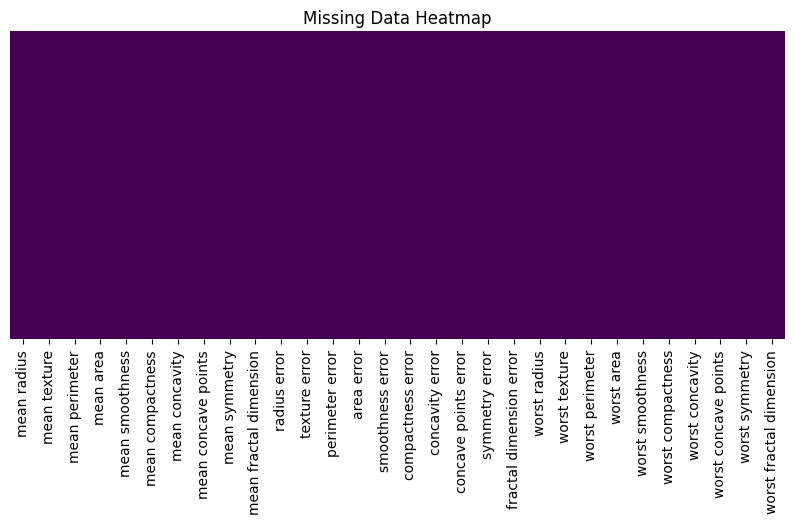

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.heatmap(X.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [13]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Printing the shapes of the split datasets
print(f"Total dataset shape:   {X.shape}")
print("-" * 30)
print(f"X_train shape:         {X_train.shape}  (80%)")
print(f"y_train shape:         {y_train.shape}")
print("-" * 30)
print(f"X_test shape:          {X_test.shape}   (20%)")
print(f"y_test shape:          {y_test.shape}")

# Double-check the math:
train_pct = (len(X_train) / len(X)) * 100
test_pct = (len(X_test) / len(X)) * 100
print(f"\nActual Split Ratio: {train_pct:.1f}% Train / {test_pct:.1f}% Test")

Total dataset shape:   (569, 30)
------------------------------
X_train shape:         (455, 30)  (80%)
y_train shape:         (455,)
------------------------------
X_test shape:          (114, 30)   (20%)
y_test shape:          (114,)

Actual Split Ratio: 80.0% Train / 20.0% Test


In [17]:
# Initialize the model
dt_baseline = DecisionTreeClassifier()

# Train the model
dt_baseline.fit(X_train, y_train)

# Make predictions
dt_preds = dt_baseline.predict(X_test)

print(f"Baseline Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(classification_report(y_test, dt_preds))

Baseline Decision Tree Accuracy: 0.9386
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        43
           1       0.96      0.94      0.95        71

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



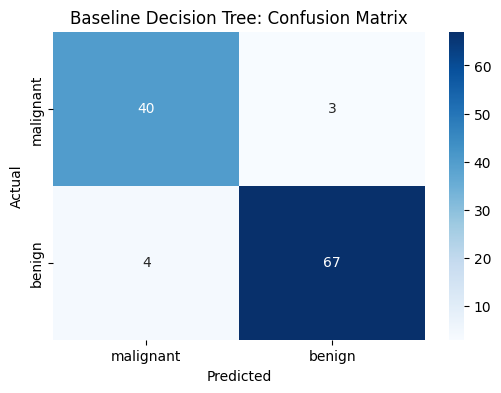


Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        43
      benign       0.96      0.94      0.95        71

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, dt_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline Decision Tree: Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, dt_preds, target_names=data.target_names))

In [25]:
# Initialize Random Forest with 100 trees
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict and Evaluate
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Baseline Decision Tree Acc: {accuracy_score(y_test, dt_preds):.4f}")
print(f"Random Forest Acc:          {rf_acc:.4f}")

Baseline Decision Tree Acc: 0.9386
Random Forest Acc:          0.9649


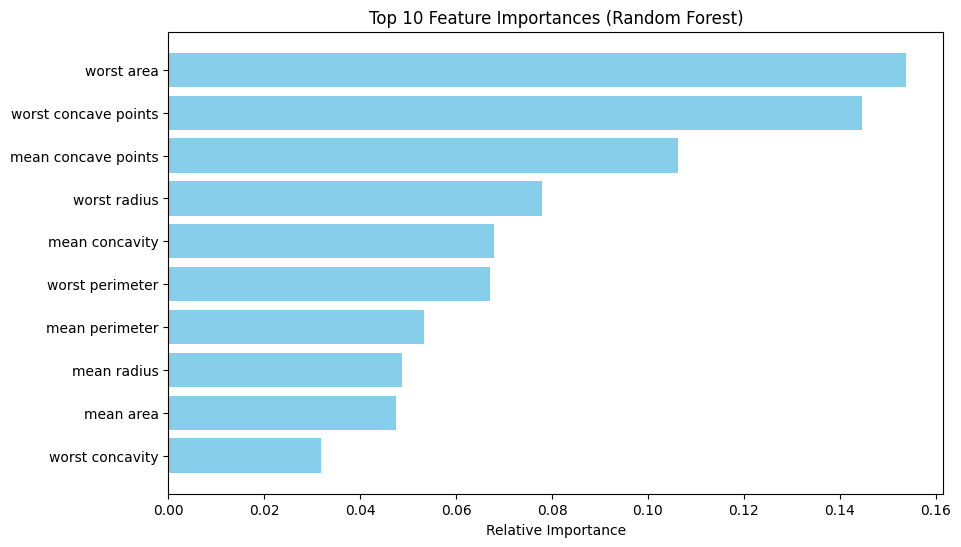

In [26]:
# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [27]:
rf_params = {
    "n_estimators": [100, 200], #no of trees
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5] }

In [28]:
# Initialize the classifier
est = RandomForestClassifier(random_state=42)

# Set up the Grid Search
rf_grid = GridSearchCV(est, rf_params)

# Fit the grid search to the data
rf_grid.fit(X_train, y_train)

# Print the best parameters found
print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [29]:
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [30]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.9385964912280702
Random Forest Accuracy: 0.9649122807017544


In [31]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Initialize the Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,      # 5-fold cross-validation
                           n_jobs=-1, # Use all available CPU cores
                           verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 50}


In [32]:
# Use the best model found by GridSearchCV
best_rf1 = grid_search.best_estimator_

# Predict and evaluate
best_rf_preds = best_rf1.predict(X_test)
best_rf_acc = accuracy_score(y_test, best_rf_preds)

print(f"Standard RF Accuracy: {rf_acc:.4f}")
print(f"Tuned RF Accuracy:    {best_rf_acc:.4f}")

Standard RF Accuracy: 0.9649
Tuned RF Accuracy:    0.9737


In [33]:
# AdaBoostClassifier

# Initialize AdaBoost
# n_estimators: Number of sequential trees to build
# learning_rate: How much weight we give to each tree's correction
ada_model = AdaBoostClassifier(random_state=42)

# Train the model
ada_model.fit(X_train, y_train)

# Make predictions
ada_preds = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, ada_preds)

print(f"AdaBoost Accuracy: {ada_acc:.4f}")

AdaBoost Accuracy: 0.9649


In [34]:
# Defining the Hyperparameter Grid for Tuning
ada_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1]
}

# Grid Search with AdaBoost
est = AdaBoostClassifier(random_state=42)
ada_grid = GridSearchCV(est, ada_params)
ada_grid.fit(X_train, y_train)

# Print the Optimized Parameters
print("Best Ada Params:", ada_grid.best_params_)

Best Ada Params: {'learning_rate': 1, 'n_estimators': 50}


In [35]:
best_ada = ada_grid.best_estimator_
y_pred_ada = best_ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [36]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

# Model Prediction and Accuracy Evaluation
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.956140350877193


In [37]:
# Defining the Hyperparameter Grid for Tuning
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5]
}

In [38]:
# Grid Search with AdaBoost
est = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(est, gb_params)
gb_grid.fit(X_train, y_train)

# Print the Optimized Parameters
print("Best Ada Params:", gb_grid.best_params_)

Best Ada Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}


In [39]:
best_gb = gb_grid.best_estimator_
y_pred_gb = best_gb.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

AdaBoost Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [42]:
#XGBClassifier
from xgboost import XGBClassifier

# Initial Training
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

# Predictions and Accuracy
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Parameter Grid for Tuning
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1]
}

# Grid Search
est = XGBClassifier(random_state=42)
xgb_grid = GridSearchCV(est, xgb_params)
xgb_grid.fit(X_train, y_train)
print("Best XGB Params:", xgb_grid.best_params_)

XGBoost Accuracy: 0.956140350877193
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [43]:
# Evaluate the best estimator found by Grid Search
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [46]:
y_pred_dt = dt_baseline.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_ada = best_ada.predict(X_test)
y_pred_gb = best_gb.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

In [47]:
results = pd.DataFrame(
{ "Model":
["Decision Tree", "Random Forest", "AdaBoost", "Gradient Boosting", "XGBoost"],
"Accuracy": [ accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_ada), accuracy_score(y_test, y_pred_gb), accuracy_score(y_test, y_pred_xgb) ],
"Precision": [ precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_ada), precision_score(y_test, y_pred_gb), precision_score(y_test, y_pred_xgb) ],
"Recall": [ recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_ada), recall_score(y_test, y_pred_gb), recall_score(y_test, y_pred_xgb) ],
"F1 Score": [ f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_ada), f1_score(y_test, y_pred_gb), f1_score(y_test, y_pred_xgb) ],
"ROC AUC": [ roc_auc_score(y_test, y_pred_dt), roc_auc_score(y_test, y_pred_rf), roc_auc_score(y_test, y_pred_ada), roc_auc_score(y_test, y_pred_gb), roc_auc_score(y_test, y_pred_xgb) ] })

print(results)

               Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0      Decision Tree  0.938596   0.957143  0.943662  0.950355  0.936947
1      Random Forest  0.964912   0.958904  0.985915  0.972222  0.958074
2           AdaBoost  0.964912   0.958904  0.985915  0.972222  0.958074
3  Gradient Boosting  0.956140   0.958333  0.971831  0.965035  0.951032
4            XGBoost  0.956140   0.958333  0.971831  0.965035  0.951032
